# Baseline CP1
### ML-задача в проекте
Регрессия (предсказать зарплату вакансии)

### Что является таргетом в vacancies_clean.parquet
salary_rub

### Какие типы фичей преобладают в датасете
Смешанные... текст + числа + категории

Логика baseline такая... одна простая модель «из коробки» Ridge/Linear Regression без feature engineering

In [34]:
import os
import json
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import BaseEstimator, TransformerMixin

warnings.filterwarnings("ignore")

In [35]:
SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

In [36]:
DATA_PATH = Path("../data/processed/vacancies_clean.parquet")
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(DATA_PATH)
df.head()

,id,link,name,description,experience,employer_id,employer_name,employer_type,employer_industry_id,employer_industry_name,accept_kids,accept_handicapped,schedule,employment,region_id,region_name,region_district_id,region_district_name,role_id,role_name,description_length,skills,skills_count,languages_parsed,languages_count,has_test,is_premium,salary_rub
0,79789667,https://hh.ru/vacancy/79789667,Консультант в Тинькофф Банк (удалённо),Обязанности: Тинькофф – первый онлайн банк в Р...,0,78638,Тинькофф,company,0,None,False,False,remote,part,598,Челябинская область,5,Уральский,83,"Оператор call-центра, специалист контактного ц...",2705,[],0,[],0,False,False,38000.0
1,79812238,https://hh.ru/vacancy/79812238,Инженер-технолог (беспилотие),АО «Научно-производственное предприятие «Радар...,3-6,167893,Радар ММС,company,0,None,False,False,full_day,full,475,Санкт-Петербург,2,Северо-Западный,40,Другое,1339,[],0,[],0,False,False,70000.0
2,83549154,https://hh.ru/vacancy/83549154,Повар-универсал,"Универсамы ""Бегемаг"" - это современная, стабил...",1-3,5829213,Наша Кухня Универсамы Бегемаг (Комбинат Питания),company,0,None,False,False,shift,full,263,Кемеровская область,6,Сибирский,94,"Повар, пекарь, кондитер",1032,[],0,[],0,False,False,45000.0
3,83549271,https://hh.ru/vacancy/83549271,Продавец (Чебоксары),Сеть магазинов одежды CLEVER приглашает на раб...,0,923386,Клевер Восток,company,0,None,False,False,flexible,full,613,Чувашская Республика,4,Приволжский,97,"Продавец-консультант, продавец-кассир",783,[],0,[],0,False,False,40000.0
4,83539369,https://hh.ru/vacancy/83539369,Консультант Тинькофф Бизнес (удалённо),Тинькофф Бизнес на связи с клиентами 24/7 по т...,0,78638,Тинькофф,company,0,None,False,True,remote,full,227,Калининградская область,2,Северо-Западный,83,"Оператор call-центра, специалист контактного ц...",2870,[],0,[],0,False,False,41500.0


In [37]:
TARGET = "salary_rub"

print("Статистика таргета")
print(df[TARGET].describe())

Статистика таргета
count    3.948800e+04
mean     7.999486e+04
std      6.088678e+04
min      1.000000e+04
25%      4.500000e+04
50%      6.000000e+04
75%      1.000000e+05
max      3.000000e+06
Name: salary_rub, dtype: float64


In [38]:
print("Исключаем из фичей", [TARGET])

feature_cols = [c for c in df.columns if c not in [TARGET]]
print(f"Итого фичей {len(feature_cols)}")

Исключаем из фичей ['salary_rub']
Итого фичей 27


In [39]:
salary_bins = pd.qcut(np.log1p(df[TARGET]), q=10, labels=False, duplicates="drop")

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=salary_bins,
)
temp_bins = salary_bins.loc[temp_df.index]

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_bins,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

X_train = train_df[feature_cols]
X_val = val_df[feature_cols]
X_test = test_df[feature_cols]

y_train = np.log1p(train_df[TARGET].values)
y_val = np.log1p(val_df[TARGET].values)
y_test = np.log1p(test_df[TARGET].values)

print(f"train {len(train_df):>7,}  ({len(train_df) / len(df):.1%})")
print(f"val {len(val_df):>7,}  ({len(val_df) / len(df):.1%})")
print(f"test {len(test_df):>7,}  ({len(test_df) / len(df):.1%})")

train  27,641  (70.0%)
val   5,923  (15.0%)
test   5,924  (15.0%)


## Группировка колонок

Та же логика, что в `01_eda.ipynb` ... отделяем id, текст, списки, булевы, числовые и категориальные колонки. Это нужно, чтобы дальше собрать `ColumnTransformer` для baseline без feature engineering ... простые преобразования для каждого типа

In [40]:
id_cols = [c for c in ["id", "link"] if c in X_train.columns]
text_cols = [c for c in ["name", "description"] if c in X_train.columns]
list_cols = [c for c in ["skills", "languages_parsed"] if c in X_train.columns]

bool_cols = [c for c in X_train.select_dtypes(include="bool").columns]
id_like_num_cols = [
    c for c in X_train.columns
    if c.endswith("_id") and c != "id" and pd.api.types.is_numeric_dtype(X_train[c])
]

num_cols = [
    c for c in X_train.select_dtypes(include=[np.number]).columns
    if c not in id_like_num_cols
]

cat_cols = [
    c for c in X_train.columns
    if c not in id_cols + text_cols + list_cols + bool_cols + num_cols + id_like_num_cols
]

# id-шники сами по себе для baseline бесполезны поэтому из фичей их выкинем
drop_cols = id_cols + id_like_num_cols

# страховка ... таргет не должен оказаться ни в одной из групп фичей
assert TARGET not in num_cols + cat_cols + bool_cols + text_cols + list_cols, \
    f"Таргет {TARGET} попал в фичи ... проверь сборку колонок"

print("text_cols", text_cols)
print("list_cols", list_cols)
print("bool_cols", bool_cols)
print("num_cols", num_cols)
print("cat_cols", cat_cols)
print("drop_cols", drop_cols)

text_cols ['name', 'description']
list_cols ['skills', 'languages_parsed']
bool_cols ['accept_kids', 'accept_handicapped', 'has_test', 'is_premium']
num_cols ['description_length', 'skills_count', 'languages_count']
cat_cols ['experience', 'employer_id', 'employer_name', 'employer_type', 'employer_industry_name', 'schedule', 'employment', 'region_name', 'region_district_name', 'role_name']
drop_cols ['id', 'link', 'employer_industry_id', 'region_id', 'region_district_id', 'role_id']


## Подготовка фичей под baseline

- Числовые ... медианная импутация + StandardScaler
- Категориальные ... импутация константой `missing` + OneHotEncoder с `min_frequency`, чтобы не взорваться от редких employer_id / region_id
- Булевы ... приводим к int
- Текстовые поля `name` и `description` ... сольём в одну строку и прогоним через TF-IDF (одна фича на текст ... это всё ещё «модель из коробки», не feature engineering)
- Списочные `skills` / `languages_parsed` ... склеиваем в строку и тоже через TF-IDF

Те же преобразования будут применены и к val, и к test, причём fit делается ТОЛЬКО на train, чтобы не было утечки

In [41]:
from sklearn.base import BaseEstimator, TransformerMixin

In [47]:
class ListToStringTransformer(BaseEstimator, TransformerMixin):
    """Превращает колонку со списками строк в одну строку через пробел.
    Нужно, чтобы потом скормить это TfidfVectorizer'у."""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # X ... pandas Series или массив со списками
        s = pd.Series(X.ravel() if hasattr(X, "ravel") else X)
        return s.apply(self._join).values

    @staticmethod
    def _join(x):
        if x is None:
            return ""
        try:
            return " ".join(str(item) for item in x)
        except TypeError:
            return str(x)


class TextConcatTransformer(BaseEstimator, TransformerMixin):
    """Склеивает несколько текстовых колонок в одну строку"""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df_ = pd.DataFrame(X)
        return df_.fillna("").astype(str).agg(" ".join, axis=1).values


class BoolToIntTransformer(BaseEstimator, TransformerMixin):
    """Переводит булевы колонки в int. SimpleImputer не работает с dtype=bool,
    поэтому сначала кастуем, потом (если надо) можно импутировать"""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df_ = pd.DataFrame(X)
        # пропуски в bool превратятся в NaN после astype, поэтому fillna(False) на всякий случай
        return df_.fillna(False).astype(int).values

In [49]:
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("ohe", OneHotEncoder(
        handle_unknown="infrequent_if_exist",
        min_frequency=20,
        sparse_output=True,
    )),
])

# bool -> int напрямую, без SimpleImputer (он не умеет в dtype=bool)
bool_pipe = Pipeline(steps=[
    ("to_int", BoolToIntTransformer()),
])

text_pipe = Pipeline(steps=[
    ("concat", TextConcatTransformer()),
    ("tfidf", TfidfVectorizer(
        max_features=20_000,
        ngram_range=(1, 1),
        min_df=5,
        sublinear_tf=True,
    )),
])

skills_pipe = Pipeline(steps=[
    ("join", ListToStringTransformer()),
    ("tfidf", TfidfVectorizer(
        max_features=2_000,
        token_pattern=r"[^\s][^\s]*",
        min_df=3,
        sublinear_tf=True,
    )),
])

languages_pipe = Pipeline(steps=[
    ("join", ListToStringTransformer()),
    ("tfidf", TfidfVectorizer(
        max_features=200,
        min_df=2,
    )),
])

transformers = []
if num_cols:
    transformers.append(("num", numeric_pipe, num_cols))
if cat_cols:
    transformers.append(("cat", categorical_pipe, cat_cols))
if bool_cols:
    transformers.append(("bool", bool_pipe, bool_cols))
if text_cols:
    transformers.append(("text", text_pipe, text_cols))
if "skills" in list_cols:
    transformers.append(("skills", skills_pipe, "skills"))
if "languages_parsed" in list_cols:
    transformers.append(("lang", languages_pipe, "languages_parsed"))

preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder="drop",
    sparse_threshold=0.3,
)

print(f"Преобразований в ColumnTransformer {len(transformers)}")
for name, _, cols in transformers:
    cols_repr = cols if isinstance(cols, str) else f"{len(cols)} cols"
    print(f"  - {name:8s} -> {cols_repr}")

Преобразований в ColumnTransformer 6
  - num      -> 3 cols
  - cat      -> 10 cols
  - bool     -> 4 cols
  - text     -> 2 cols
  - skills   -> skills
  - lang     -> languages_parsed


## Обучение baseline

Учим две модели «из коробки»
- `DummyRegressor(strategy="median")` ... совсем тупой baseline, чтобы убедиться, что наша нормальная модель его обгоняет
- `LinearRegression()` ... обычная линейная регрессия, дефолтные параметры

Учим на `log1p(salary_rub)`, метрики считаем в рублях через `expm1`

In [50]:
def evaluate(y_true_log, y_pred_log, name=""):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    # отрицательные предсказания зарплат не имеют смысла, обрезаем по нижней границе
    y_pred = np.clip(y_pred, 10_000, None)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "model": name,
        "MAE_rub": mae,
        "RMSE_rub": rmse,
        "R2": r2,
    }

In [51]:
dummy = DummyRegressor(strategy="median")
dummy.fit(X_train, y_train)

dummy_val_pred = dummy.predict(X_val)
dummy_metrics = evaluate(y_val, dummy_val_pred, name="DummyRegressor (median)")
print(dummy_metrics)

{'model': 'DummyRegressor (median)', 'MAE_rub': np.float64(36581.71230795205), 'RMSE_rub': np.float64(62218.91913839899), 'R2': -0.1153910253187187}


In [52]:
linreg_pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", LinearRegression()),
])

linreg_pipe.fit(X_train, y_train)

linreg_val_pred = linreg_pipe.predict(X_val)
linreg_metrics = evaluate(y_val, linreg_val_pred, name="LinearRegression")
print(linreg_metrics)

{'model': 'LinearRegression', 'MAE_rub': np.float64(104052.9451522795), 'RMSE_rub': np.float64(672814.5950784857), 'R2': -129.42865891491323}


In [53]:
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

cv_scores = cross_val_score(
    linreg_pipe,
    X_train,
    y_train,
    cv=kf,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
)

print(f"CV MAE ... mean={-cv_scores.mean():.4f}, std={cv_scores.std():.4f}")

/var/folders/3w/zypl0rk17z70v4s062hnsn0r0000gn/T/ipykernel_7208/118342414.py:10: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
/var/folders/3w/zypl0rk17z70v4s062hnsn0r0000gn/T/ipykernel_7208/118342414.py:10: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
/var/folders/3w/zypl0rk17z70v4s062hnsn0r0000gn/T/ipykernel_7208/118342414.py:10: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
/var/folders/3w/zypl0rk17z70v4s062hnsn0r0000gn/T/ipykernel_7208/118342414.py:10: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
/var/folders/3w/

CV MAE ... mean=1.3969, std=0.0213


/var/folders/3w/zypl0rk17z70v4s062hnsn0r0000gn/T/ipykernel_7208/118342414.py:10: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.


## Сводная таблица метрик baseline на val

In [54]:
results_df = pd.DataFrame([dummy_metrics, linreg_metrics]).set_index("model")
results_df = results_df.round(2)
results_df

,MAE_rub,RMSE_rub,R2
model,,,
DummyRegressor (median),36581.71,62218.92,-0.12
LinearRegression,104052.95,672814.60,-129.43


## Финальная оценка baseline на test

Считаем метрики на отложенной выборке `test` ... только один раз, после фиксации baseline

In [55]:
linreg_test_pred = linreg_pipe.predict(X_test)
linreg_test_metrics = evaluate(y_test, linreg_test_pred, name="LinearRegression (test)")

dummy_test_pred = dummy.predict(X_test)
dummy_test_metrics = evaluate(y_test, dummy_test_pred, name="Dummy (test)")

test_results = pd.DataFrame([dummy_test_metrics, linreg_test_metrics]).set_index("model").round(2)
test_results

,MAE_rub,RMSE_rub,R2
model,,,
Dummy (test),36769.94,71357.45,-0.09
LinearRegression (test),126406.77,1133461.85,-273.39


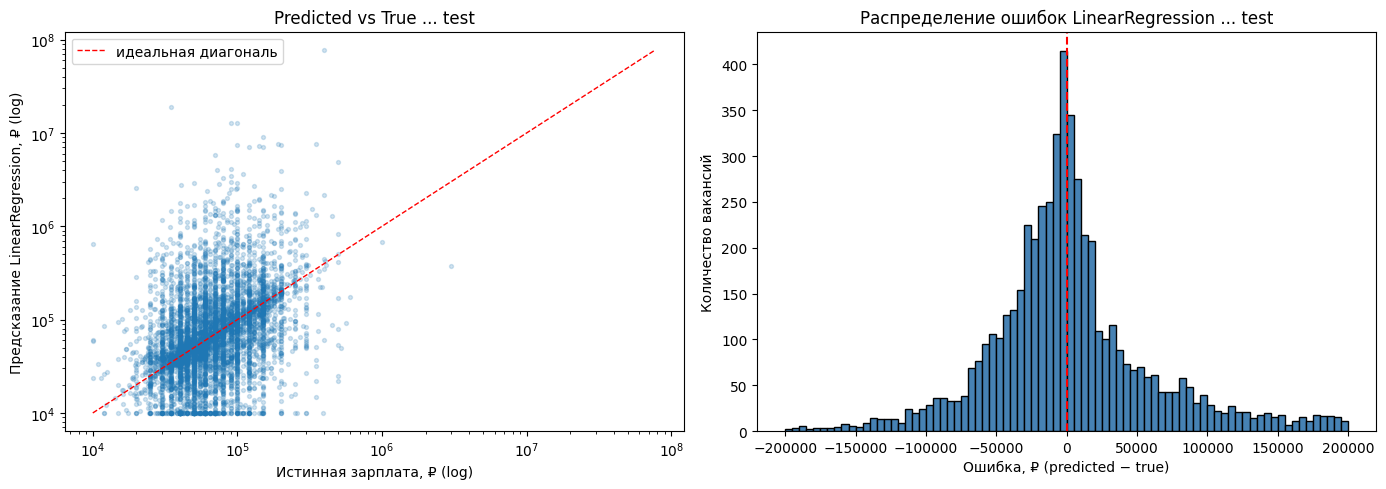

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

y_test_rub = np.expm1(y_test)
linreg_pred_rub = np.clip(np.expm1(linreg_test_pred), 10_000, None)

# scatter истинное vs предсказанное
axes[0].scatter(y_test_rub, linreg_pred_rub, alpha=0.2, s=8)
lims = [10_000, max(y_test_rub.max(), linreg_pred_rub.max())]
axes[0].plot(lims, lims, "r--", lw=1, label="идеальная диагональ")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Истинная зарплата, ₽ (log)")
axes[0].set_ylabel("Предсказание LinearRegression, ₽ (log)")
axes[0].set_title("Predicted vs True ... test")
axes[0].legend()

# распределение ошибок
errors = linreg_pred_rub - y_test_rub
axes[1].hist(errors, bins=80, range=(-200_000, 200_000), color="steelblue", edgecolor="black")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Ошибка, ₽ (predicted − true)")
axes[1].set_ylabel("Количество вакансий")
axes[1].set_title("Распределение ошибок LinearRegression ... test")

plt.tight_layout()
plt.show()